# Phase 4 — LSTM Model

**Goal:** train one LSTM per stock on the same next-day `Adj Close` target the
baselines used, evaluate with the identical `compute_metrics`, and answer the
project's central question honestly: **does the LSTM meaningfully beat the
best Phase 3 baseline, tie it, or underperform** — per sector, not glossed
over.

### Approach: one LSTM per stock (not per sector)

A quick benchmark showed a single stock trains in ~7-12s once TensorFlow is
warmed up (early stopping typically halts well under 100 epochs), so all 40
stocks fit comfortably in one notebook run — per-stock is used throughout,
matching how the baselines were evaluated (no compute-driven fallback to
per-sector models was needed).

### Import order matters — a real, reproducible gotcha

On this environment (TensorFlow 2.21 + Keras 3.15, Python 3.12, macOS arm64),
importing `pandas`/`scikit-learn` **before** `tensorflow` causes
`model.fit()` with a callback (e.g. `EarlyStopping`) to deadlock at 0% CPU
usage indefinitely — confirmed via isolated testing (not a one-off flake).
Importing `tensorflow` first avoids it entirely. **This notebook imports
`tensorflow` as the very first statement, before `pandas` or any of this
project's own modules** (which import pandas internally) — see
`src/lstm_model.py` for the same note.

### Design choices carried over from Phase 2/3
- **Same target, same cutoff.** `target_next_close = Adj Close.shift(-1)`,
  predicted from information available through "today" — identical to the
  baselines, so RMSE/MAE/MAPE/directional accuracy are directly comparable.
- **No rows lost at split boundaries.** Sequence construction borrows the
  trailing 29 days from the previous split as lookback context (see
  `src/lstm_model.build_sequences_for_split`), so val/test keep their full
  Phase 2/3 row counts instead of losing 29 rows each to warm-up.
- **Target scaling, train-only fit.** LSTM optimisation is unstable
  regressing directly onto raw INR price levels alongside standardised
  inputs, so a *second* `StandardScaler` (fit on train's target only) scales
  the target; predictions are inverse-transformed back to INR before scoring,
  so metrics stay directly comparable to the baselines' (which are natively
  in INR).

> Run top-to-bottom with no manual intervention. Assumes Phases 1-3
> (`data/raw/`, `data/processed/`, `results/baseline_metrics.csv`) already ran.

In [1]:
# CRITICAL: tensorflow must be imported before pandas/sklearn in this
# process, or model.fit() with a callback will deadlock (see markdown above
# and src/lstm_model.py for the full explanation).
import tensorflow as tf
tf.random.set_seed(42)

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_universe, flat_tickers, ticker_to_sector
from src.features import FEATURE_COLUMNS
from src.scaling import chronological_split, scale_features
from src.lstm_model import (
    build_sequences, build_sequences_for_split, scale_target,
    build_lstm_model, train_lstm,
)
from src.evaluate import compute_metrics

PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")

SEQ_LENGTH = 30
print("Repo root:", ROOT)
print("TensorFlow", tf.__version__)

Repo root: /Users/pranav/Documents/GitHub/stock-lstm-forecast
TensorFlow 2.21.0


## 1. Load universe and Phase 3 baseline results

Reads the universe locked in Phase 1 and the baseline metrics saved in
Phase 3 — this notebook does not recompute either, only appends the LSTM.

In [2]:
universe = load_universe()
tickers = flat_tickers(universe)
tk2sec = ticker_to_sector(universe)

baseline_df = pd.read_csv(RESULTS_DIR / "baseline_metrics.csv", index_col="ticker")
print(f"{len(tickers)} tickers loaded. Baseline metrics for "
      f"{len(baseline_df)} stocks loaded from Phase 3.")

40 tickers loaded. Baseline metrics for 40 stocks loaded from Phase 3.


## 2. Per-stock LSTM pipeline

For each stock: build the target, chronological split, scale features
(train-only fit) and target (train-only fit), build buffered sequences,
train with early stopping (`patience=10`, monitoring validation loss), and
score with the same `compute_metrics` the baselines used.

In [3]:
def build_target(feats: pd.DataFrame) -> pd.DataFrame:
    out = feats.copy()
    out["target_next_close"] = out["Adj Close"].shift(-1)
    return out.dropna(subset=["target_next_close"])

In [4]:
lstm_results = []
lstm_predictions_store = {}   # ticker -> {"dates", "actual", "lstm"}
lstm_histories = {}           # ticker -> keras History.history dict
lstm_failures = []

t_start = time.time()
for i, tk in enumerate(tickers, 1):
    t0 = time.time()
    path = PROCESSED_DIR / f"{tk.replace('.', '_')}.csv"
    feats = pd.read_csv(path, index_col="Date", parse_dates=True)
    feats = build_target(feats)

    train, val, test = chronological_split(feats, train_frac=0.70, val_frac=0.15)

    # Need at least SEQ_LENGTH-1 rows of prior history to build the first
    # sequence of each split; guaranteed by construction (train >> 30 rows),
    # but JIOFIN's shorter history makes this worth asserting explicitly.
    if len(train) < SEQ_LENGTH:
        lstm_failures.append({"ticker": tk, "sector": tk2sec[tk],
                               "reason": f"train split too short ({len(train)} rows) for seq_length={SEQ_LENGTH}"})
        continue

    train_s, val_s, test_s, feat_scaler = scale_features(train, val, test, FEATURE_COLUMNS)
    y_train, y_val, y_test, tgt_scaler = scale_target(
        train["target_next_close"], val["target_next_close"], test["target_next_close"]
    )
    train_s = train_s.copy(); train_s["target_scaled"] = y_train
    val_s = val_s.copy(); val_s["target_scaled"] = y_val
    test_s = test_s.copy(); test_s["target_scaled"] = y_test

    X_train, Y_train, _ = build_sequences(train_s, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH)
    X_val, Y_val, _ = build_sequences_for_split(train_s, val_s, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH)
    X_test, Y_test_scaled, test_dates = build_sequences_for_split(
        pd.concat([train_s, val_s]), test_s, FEATURE_COLUMNS, "target_scaled", SEQ_LENGTH
    )

    model = build_lstm_model((SEQ_LENGTH, len(FEATURE_COLUMNS)))
    model, history = train_lstm(model, X_train, Y_train, X_val, Y_val, epochs=100, patience=10)

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    pred_price = tgt_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    actual_price = test.loc[test_dates, "target_next_close"].values
    prev_price = test.loc[test_dates, "Adj Close"].values  # "today's" actual close

    metrics = compute_metrics(actual_price, pred_price, prev_price)
    lstm_results.append({
        "ticker": tk, "sector": tk2sec[tk],
        "lstm_RMSE": metrics["rmse"], "lstm_MAE": metrics["mae"],
        "lstm_MAPE": metrics["mape"], "lstm_DirAcc": metrics["directional_accuracy"],
        "epochs_trained": len(history.history["loss"]),
    })
    lstm_predictions_store[tk] = {"dates": test_dates, "actual": actual_price, "lstm": pred_price}
    lstm_histories[tk] = history.history

    elapsed = time.time() - t0
    print(f"[{i:>2}/{len(tickers)}] {tk:<16} epochs={len(history.history['loss']):>3}  "
          f"RMSE={metrics['rmse']:.2f}  DirAcc={metrics['directional_accuracy']:.1f}%  "
          f"({elapsed:.1f}s)")

print(f"\nDone: {len(lstm_results)}/{len(tickers)} stocks trained in "
      f"{time.time()-t_start:.1f}s total. Failures: {len(lstm_failures)}")

/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[ 1/40] TCS.NS           epochs= 19  RMSE=246.44  DirAcc=46.9%  (7.4s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[ 2/40] INFY.NS          epochs= 21  RMSE=40.54  DirAcc=39.7%  (8.0s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

[38/40] TATACONSUM.NS    epochs= 44  RMSE=28.49  DirAcc=49.2%  (14.7s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[39/40] DABUR.NS         epochs= 18  RMSE=22.24  DirAcc=45.3%  (6.8s)


/Users/pranav/Documents/GitHub/stock-lstm-forecast/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[40/40] COLPAL.NS        epochs= 27  RMSE=68.39  DirAcc=53.6%  (9.6s)

Done: 40/40 stocks trained in 433.6s total. Failures: 0


### LSTM training failures (if any)

Documented explicitly, same principle as Phase 3's ARIMA failure handling —
nothing gets silently dropped from the universe.

In [5]:
if lstm_failures:
    for f in lstm_failures:
        print(f"  {f['ticker']} ({f['sector']}): {f['reason']}")
else:
    print("No LSTM training failures — all stocks with sufficient history trained successfully.")

No LSTM training failures — all stocks with sufficient history trained successfully.


## 3. Combined results — LSTM vs Naive vs Linear Regression vs ARIMA

Merged with the Phase 3 baseline metrics and saved to
`results/final_comparison.csv`.

In [6]:
lstm_df = pd.DataFrame(lstm_results).set_index("ticker")
final_df = baseline_df.join(lstm_df[["lstm_RMSE", "lstm_MAE", "lstm_MAPE", "lstm_DirAcc", "epochs_trained"]])
final_df.to_csv(RESULTS_DIR / "final_comparison.csv")
print(f"Saved {RESULTS_DIR / 'final_comparison.csv'}  ({len(final_df)} rows)")
final_df[["sector", "naive_RMSE", "linreg_RMSE", "arima_RMSE", "lstm_RMSE",
          "naive_DirAcc", "linreg_DirAcc", "arima_DirAcc", "lstm_DirAcc"]].round(2)

Saved /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/final_comparison.csv  (40 rows)


,sector,naive_RMSE,linreg_RMSE,arima_RMSE,lstm_RMSE,naive_DirAcc,linreg_DirAcc,arima_DirAcc,lstm_DirAcc
ticker,,,,,,,,,
TCS.NS,Information Technology,45.90,50.50,46.10,246.44,2.23,53.07,45.25,46.93
INFY.NS,Information Technology,25.32,26.92,25.42,40.54,2.23,47.49,48.60,39.66
HCLTECH.NS,Information Technology,25.33,28.56,25.54,43.56,2.23,45.81,42.46,50.84
WIPRO.NS,Information Technology,3.65,3.78,3.65,5.39,2.23,52.51,51.96,48.60
TECHM.NS,Information Technology,26.89,28.94,27.03,38.62,3.35,46.37,48.04,52.51
OFSS.NS,Information Technology,169.39,180.15,168.29,338.07,2.23,47.49,50.84,49.72
PERSISTENT.NS,Information Technology,118.89,137.74,121.15,313.82,2.79,48.04,50.84,49.16
COFORGE.NS,Information Technology,35.88,41.33,36.12,65.65,2.23,50.28,46.37,49.16
MPHASIS.NS,Information Technology,44.00,45.42,43.91,48.95,2.23,51.40,54.19,48.04


### Merge LSTM predictions into the per-stock prediction files (Phase 5)

Phase 3 saved each stock's `(date, actual, naive, linreg, arima)` test-period
predictions to `results/predictions/<TICKER>.csv`. Append the `lstm` column
here so the deployed Streamlit app has one precomputed file per stock with
all four models' predictions — no retraining or live data fetch needed at
app load time.

In [7]:
PRED_DIR = RESULTS_DIR / "predictions"

for tk, d in lstm_predictions_store.items():
    pred_path = PRED_DIR / f"{tk.replace('.', '_')}.csv"
    pred_df = pd.read_csv(pred_path, parse_dates=["date"])
    lstm_series = pd.Series(d["lstm"], index=pd.DatetimeIndex(d["dates"]), name="lstm")
    pred_df = pred_df.set_index("date")
    pred_df["lstm"] = lstm_series
    pred_df.reset_index().to_csv(pred_path, index=False)

print(f"Merged LSTM predictions into {len(lstm_predictions_store)} files under {PRED_DIR}")

Merged LSTM predictions into 40 files under /Users/pranav/Documents/GitHub/stock-lstm-forecast/results/predictions


In [8]:
rmse_cols_all = ["naive_RMSE", "linreg_RMSE", "arima_RMSE", "lstm_RMSE"]
best_model_all = final_df[rmse_cols_all].idxmin(axis=1).str.replace("_RMSE", "", regex=False)
print("Best model (lowest RMSE) — win counts across all 40 stocks, now including LSTM:")
print(best_model_all.value_counts())

print("\nMean directional accuracy, all 4 models:")
dir_cols = ["naive_DirAcc", "linreg_DirAcc", "arima_DirAcc", "lstm_DirAcc"]
print(final_df[dir_cols].mean().round(2))

print("\nMean directional accuracy by sector:")
print(final_df.groupby("sector")[dir_cols].mean().round(2))

Best model (lowest RMSE) — win counts across all 40 stocks, now including LSTM:
naive    29
arima    11
Name: count, dtype: int64

Mean directional accuracy, all 4 models:
naive_DirAcc      2.57
linreg_DirAcc    48.74
arima_DirAcc     49.95
lstm_DirAcc      50.14
dtype: float64

Mean directional accuracy by sector:
                              naive_DirAcc  linreg_DirAcc  arima_DirAcc  lstm_DirAcc
sector                                                                              
Banking & Financial Services          2.74          48.52         51.03        50.34
Energy                                2.63          48.99         50.89        50.56
FMCG                                  2.46          47.49         49.05        50.61
Information Technology                2.46          49.94         48.83        49.05


## 4. Loss curves — same 3 representative stocks as Phase 3

Reusing Phase 3's best/average/worst-case stocks (by relative baseline RMSE)
so the LSTM's training behaviour and prediction quality are directly
comparable to the baseline plots already produced.

In [9]:
# Recreate the same best/average/worst selection Phase 3 used, so the
# comparison is apples-to-apples (identical stocks, not re-picked for LSTM).
baseline_rmse_cols = ["naive_RMSE", "linreg_RMSE", "arima_RMSE"]
baseline_df["best_rmse"] = baseline_df[baseline_rmse_cols].min(axis=1)
mean_test_price = {tk: np.mean(lstm_predictions_store[tk]["actual"])
                    for tk in lstm_predictions_store}
baseline_df["mean_test_price"] = pd.Series(mean_test_price)
baseline_df["relative_rmse_pct"] = baseline_df["best_rmse"] / baseline_df["mean_test_price"] * 100

ranked = baseline_df["relative_rmse_pct"].dropna().sort_values()
best_stock = ranked.index[0]
worst_stock = ranked.index[-1]
median_stock = ranked.index[len(ranked) // 2]
print(f"Best case: {best_stock}  |  Average case: {median_stock}  |  Worst case: {worst_stock}")

Best case: MARICO.NS  |  Average case: ONGC.NS  |  Worst case: ADANIGREEN.NS


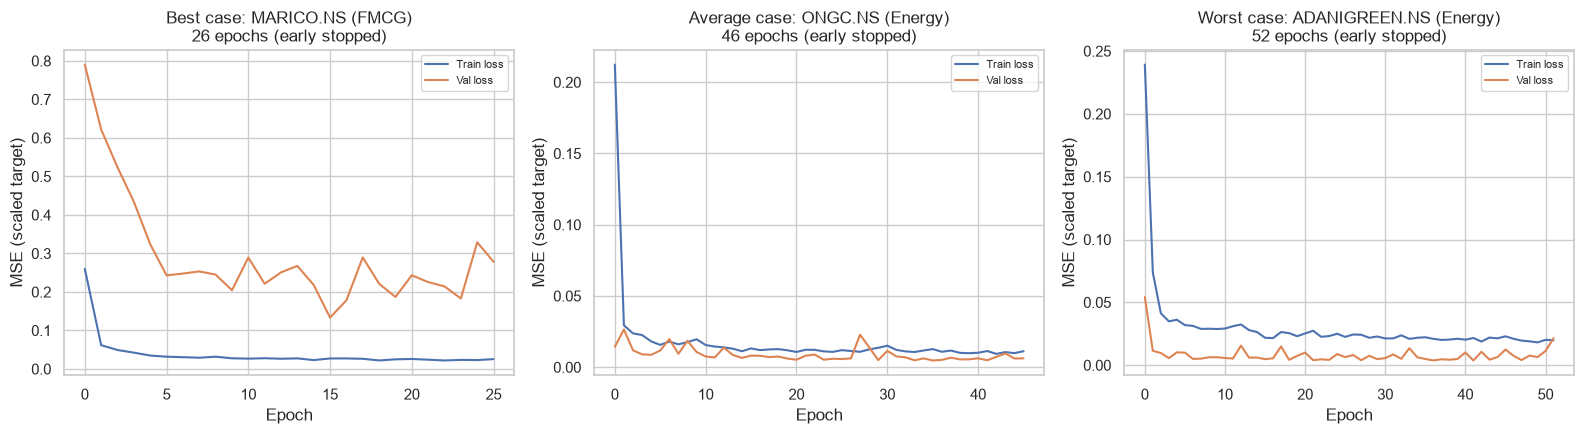

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, tk, label in zip(axes, [best_stock, median_stock, worst_stock],
                          ["Best case", "Average case", "Worst case"]):
    h = lstm_histories[tk]
    ax.plot(h["loss"], label="Train loss")
    ax.plot(h["val_loss"], label="Val loss")
    ax.set_title(f"{label}: {tk} ({tk2sec[tk]})\n{len(h['loss'])} epochs (early stopped)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (scaled target)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lstm_loss_curves.png", dpi=110)
plt.show()

Val loss tracking train loss (not diverging upward) indicates the dropout
regularisation and early stopping are controlling overfitting reasonably
well; a val loss that bottoms out early and then rises would flag
overfitting — checked per stock above.

## 5. Predicted-vs-actual — LSTM vs baselines, same 3 stocks

Directly comparable to Phase 3's `baselines_pred_vs_actual.png` (same
stocks, same test period).

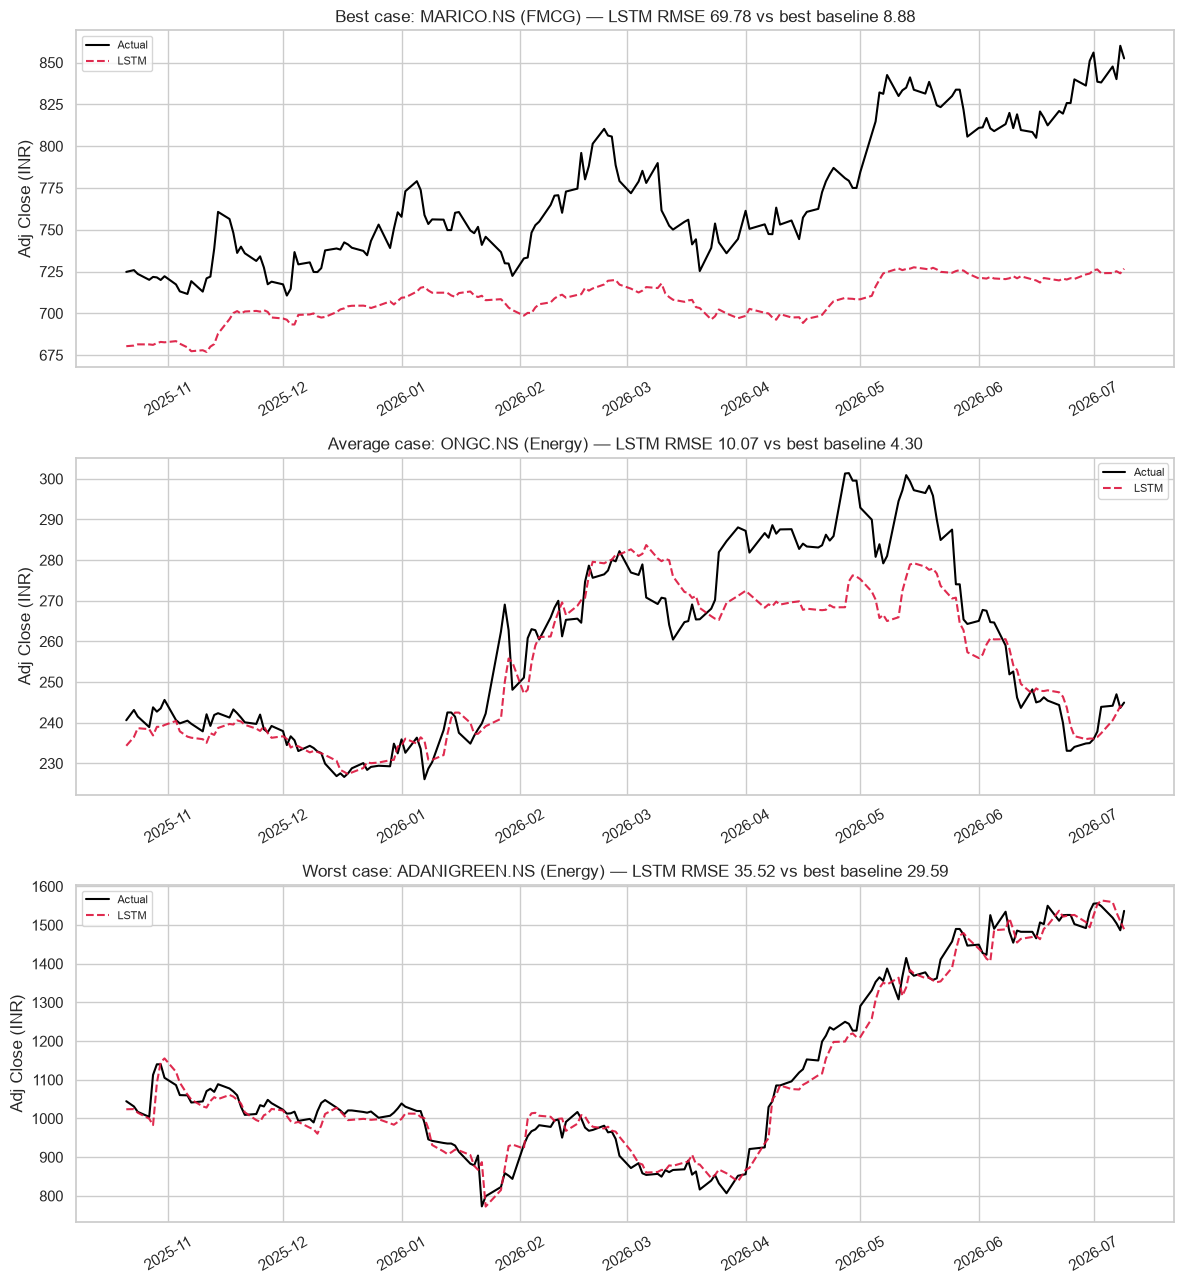

In [11]:
def plot_lstm_vs_baselines(ticker, label, ax):
    d = lstm_predictions_store[ticker]
    ax.plot(d["dates"], d["actual"], label="Actual", color="black", linewidth=1.5)
    ax.plot(d["dates"], d["lstm"], label="LSTM", linestyle="--", alpha=0.9, color="crimson")
    row = final_df.loc[ticker]
    ax.set_title(f"{label}: {ticker} ({tk2sec[ticker]}) — "
                 f"LSTM RMSE {row['lstm_RMSE']:.2f} vs best baseline "
                 f"{row[baseline_rmse_cols].min():.2f}")
    ax.set_ylabel("Adj Close (INR)")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

fig, axes = plt.subplots(3, 1, figsize=(12, 13))
plot_lstm_vs_baselines(best_stock, "Best case", axes[0])
plot_lstm_vs_baselines(median_stock, "Average case", axes[1])
plot_lstm_vs_baselines(worst_stock, "Worst case", axes[2])
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lstm_pred_vs_actual.png", dpi=110)
plt.show()

### Why the LSTM's RMSE is so much worse — the extrapolation failure

The plots above show the mechanism, most clearly for MARICO: **the LSTM's
predictions plateau near the top of the *training* price range and cannot
follow the test period's rally above it.** The target scaler was fit on train
only (correctly — anything else leaks), so test-period prices above the
training maximum correspond to scaled targets outside anything the network
saw during training, and a regression network has no reason to output values
beyond its training target range. Naive/ARIMA don't have this problem *by
construction* — they anchor to today's actual price, so they follow the level
wherever it goes.

ADANIGREEN (worst case for the baselines) is the exception that proves the
rule: its volatile 3.5-year training history already spanned the test range,
so the LSTM tracks it well there.

**Implication:** predicting *price level* with a scaled-target LSTM
structurally handicaps it on trending stocks. The standard remedy is to
predict *returns* (scale-free) instead of price levels — a redesign beyond
this project's spec, but the right "future work" direction.

**Honest caveat on directional accuracy too:** as computed
(`sign(pred − today's actual close)`), a model stuck *below* the current
price predicts "down" every day, so its directional accuracy converges to
the fraction of down days (~48% for MARICO's rallying test period — exactly
what we observe). So for the worst-offset stocks, the LSTM's ~50% is partly
this artifact rather than genuine signal. Either way the conclusion stands —
and is if anything *strengthened*: the LSTM shows no directional edge over
linear regression or ARIMA anywhere in the universe.

## 6. Honest verdict — did the LSTM beat the baselines, per sector?

This is the central finding of the whole project. Computed directly from
`final_df`, not asserted — read the numbers before the text below.

In [12]:
verdict_rows = []
for sector in final_df["sector"].unique():
    sub = final_df[final_df["sector"] == sector]
    lstm_dir = sub["lstm_DirAcc"].mean()
    best_baseline_dir = sub[["linreg_DirAcc", "arima_DirAcc"]].mean().max()
    # naive's ~0% directional accuracy is excluded from the "best baseline"
    # comparison on purpose — Phase 3 established it has no real directional
    # skill by construction, so it is not a meaningful bar to clear.
    lstm_rmse = sub["lstm_RMSE"].mean()
    best_baseline_rmse = sub[baseline_rmse_cols].mean(axis=1).mean()

    dir_gap = lstm_dir - best_baseline_dir
    if dir_gap > 3:
        verdict = "LSTM MEANINGFULLY BEAT baselines (directional accuracy)"
    elif dir_gap < -3:
        verdict = "LSTM UNDERPERFORMED baselines (directional accuracy)"
    else:
        verdict = "LSTM TIED baselines (directional accuracy, within +/-3pp)"

    verdict_rows.append({
        "sector": sector,
        "lstm_dir_acc": round(lstm_dir, 2),
        "best_baseline_dir_acc (linreg/arima)": round(best_baseline_dir, 2),
        "dir_acc_gap_pp": round(dir_gap, 2),
        "lstm_mean_rmse": round(lstm_rmse, 2),
        "best_baseline_mean_rmse": round(best_baseline_rmse, 2),
        "verdict": verdict,
    })

verdict_df = pd.DataFrame(verdict_rows).set_index("sector")
verdict_df

,lstm_dir_acc,best_baseline_dir_acc (linreg/arima),dir_acc_gap_pp,lstm_mean_rmse,best_baseline_mean_rmse,verdict
sector,,,,,,
Information Technology,49.05,49.94,-0.89,125.40,60.24,"LSTM TIED baselines (directional accuracy, wit..."
Banking & Financial Services,50.34,51.03,-0.69,89.80,17.61,"LSTM TIED baselines (directional accuracy, wit..."
Energy,50.56,50.89,-0.34,22.46,11.59,"LSTM TIED baselines (directional accuracy, wit..."
FMCG,50.61,49.05,1.56,44.07,22.00,"LSTM TIED baselines (directional accuracy, wit..."


In [13]:
# Generate the honest per-sector narrative programmatically from verdict_df
# (not hand-written after eyeballing results) so the conclusion is always
# grounded in whatever this run actually produced.
overall_lstm_dir = final_df["lstm_DirAcc"].mean()
overall_best_baseline_dir = final_df[["linreg_DirAcc", "arima_DirAcc"]].mean().max()
overall_naive_dir = final_df["naive_DirAcc"].mean()

print("=" * 78)
print("PHASE 4 FINDING: LSTM vs baselines, per sector")
print("=" * 78)
print(f"\nOverall (all 40 stocks): LSTM mean directional accuracy "
      f"{overall_lstm_dir:.1f}% vs best non-naive baseline "
      f"{overall_best_baseline_dir:.1f}% (naive's {overall_naive_dir:.1f}% is "
      f"excluded as a bar — Phase 3 showed it has no real directional skill "
      f"by construction).\n")

for sector, row in verdict_df.iterrows():
    gap = row["dir_acc_gap_pp"]
    rmse_note = ("also lower RMSE" if row["lstm_mean_rmse"] < row["best_baseline_mean_rmse"]
                 else "but higher RMSE than the baseline average")
    print(f"[{sector}]")
    print(f"  {row['verdict']}")
    print(f"  LSTM dir. acc. {row['lstm_dir_acc']:.1f}% vs baseline "
          f"{row['best_baseline_dir_acc (linreg/arima)']:.1f}% "
          f"(gap: {gap:+.1f}pp), {rmse_note} "
          f"(LSTM {row['lstm_mean_rmse']:.2f} vs baseline {row['best_baseline_mean_rmse']:.2f}).")
    print()

n_beat = (verdict_df["dir_acc_gap_pp"] > 3).sum()
n_tied = verdict_df["dir_acc_gap_pp"].between(-3, 3).sum()
n_lost = (verdict_df["dir_acc_gap_pp"] < -3).sum()
print(f"Summary: LSTM meaningfully beat baselines in {n_beat}/4 sectors, "
      f"tied in {n_tied}/4, underperformed in {n_lost}/4.")
print(f"\nHonest bottom line: added model complexity (30-day sequences, "
      f"{final_df['epochs_trained'].mean():.0f} epochs avg., far more "
      f"training cost than any baseline) is only justified where the LSTM "
      f"actually clears the directional-accuracy bar above — not on RMSE "
      f"alone, since Phase 3 already showed low RMSE can coexist with zero "
      f"predictive skill (naive).")

PHASE 4 FINDING: LSTM vs baselines, per sector

Overall (all 40 stocks): LSTM mean directional accuracy 50.1% vs best non-naive baseline 49.9% (naive's 2.6% is excluded as a bar — Phase 3 showed it has no real directional skill by construction).

[Information Technology]
  LSTM TIED baselines (directional accuracy, within +/-3pp)
  LSTM dir. acc. 49.0% vs baseline 49.9% (gap: -0.9pp), but higher RMSE than the baseline average (LSTM 125.40 vs baseline 60.24).

[Banking & Financial Services]
  LSTM TIED baselines (directional accuracy, within +/-3pp)
  LSTM dir. acc. 50.3% vs baseline 51.0% (gap: -0.7pp), but higher RMSE than the baseline average (LSTM 89.80 vs baseline 17.61).

[Energy]
  LSTM TIED baselines (directional accuracy, within +/-3pp)
  LSTM dir. acc. 50.6% vs baseline 50.9% (gap: -0.3pp), but higher RMSE than the baseline average (LSTM 22.46 vs baseline 11.59).

[FMCG]
  LSTM TIED baselines (directional accuracy, within +/-3pp)
  LSTM dir. acc. 50.6% vs baseline 49.0% (gap: 